# Uma Desai COMP 541
This code demonstrates:
- **Architecture Design** — LSTM **and** 1D CNN
- **Model Training Setup**
- **Regularization & Generalization**
- **Preliminary Results** — Loss curves
- **Evaluation Metrics** — RMSE, MAE, MAPE

All of my logic is inside `src/models.py`; this notebook just imports and runs it.

The two architectures share an identical training loop (chronological 80/20 split, forward-chained inner validation for EarlyStopping,MinMax-scaled Profit target, Adam(lr=0.001), MSE loss, batch=16 epochs=50, Dropout 0.20, L2(0.01)) so the performance differences are all architectural.

In [ ]:
# connect to path so we can import the team's modules
import sys, os
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
SRC = PROJECT_ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from data_preprocessing import load_data, data_cleaning
from models import (
    aggregate_daily, chronological_split,
    build_lstm, train_lstm,
    build_cnn, train_cnn,
    evaluate_on_test,
    plot_loss_curves, plot_predictions,
)
print("Modules loaded.")

I0000 00:00:1777592213.974639    3707 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1777592213.975507    3707 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


I0000 00:00:1777592216.100058    3707 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1777592216.100972    3707 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


Modules loaded.


In [ ]:
TARGET = "Profit"   # drop Revenue, keep Profit (corr 0.97)
WINDOW = 10
EPOCHS = 50
SEED = 42

df = load_data()
df = data_cleaning(df)

daily = aggregate_daily(df, target=TARGET)
daily_train, daily_test = chronological_split(daily, train_frac=0.8)

print(f"Daily series : {len(daily)} days  ({daily.index.min().date()} -> {daily.index.max().date()})")
print(f"Train        : {len(daily_train):4d} days")
print(f"Test (held)  : {len(daily_test):4d} days")
print(f"Zero-sale days in test: {(daily_test[TARGET] == 0).sum()} "
      f"({100*(daily_test[TARGET] == 0).mean():.1f}%)")

Daily series : 1003 days  (2023-01-02 -> 2025-09-30)
Train        :  802 days
Test (held)  :  201 days
Zero-sale days in test: 64 (31.8%)


## Architecture — LSTM

| Layer    | Spec                                                  | Params |
|----------|-------------------------------------------------------|-------:|
| Input    | (window=10, 1)                                        |      0 |
| LSTM     | 50 units, ReLU, kernel L2(0.01)                       | 10,400 |
| Dropout  | 0.20                                                  |      0 |
| Dense    | 1 unit, kernel L2(0.01)                               |     51 |
| **Total** |                                                      | **10,451** |

In [ ]:
build_lstm(window=WINDOW).summary()

E0000 00:00:1777592216.560948    3707 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 50)             │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
lstm_model, lstm_history, lstm_scaler = train_lstm(
    daily_train, target=TARGET, window=WINDOW,
    hidden_units=50, dropout=0.20, l2_coeff=0.01, lr=0.001,
    epochs=EPOCHS, batch_size=16, val_frac=0.20,
    early_stop_patience=10, seed=SEED, verbose=0,
)
lstm_metrics, lstm_preds = evaluate_on_test(
    lstm_model, lstm_scaler, daily_train, daily_test,
    target=TARGET, window=WINDOW,
)
print(f"LSTM trained for {len(lstm_history.history['loss'])} epochs")
print(f"Final training MSE  : {lstm_history.history['loss'][-1]:.4f}")
print(f"Final validation MSE: {lstm_history.history['val_loss'][-1]:.4f}\n")
print("LSTM test metrics:")
for k, v in lstm_metrics.items():
    print(f"  {k:>16s}: {v:,.4f}" if isinstance(v, float) else f"  {k:>16s}: {v}")

LSTM trained for 50 epochs
Final training MSE  : 0.0272
Final validation MSE: 0.0281

LSTM test metrics:
      rmse_dollars: 101.8250
       mae_dollars: 79.1176
          mape_pct: 112.2446
     n_test_points: 201


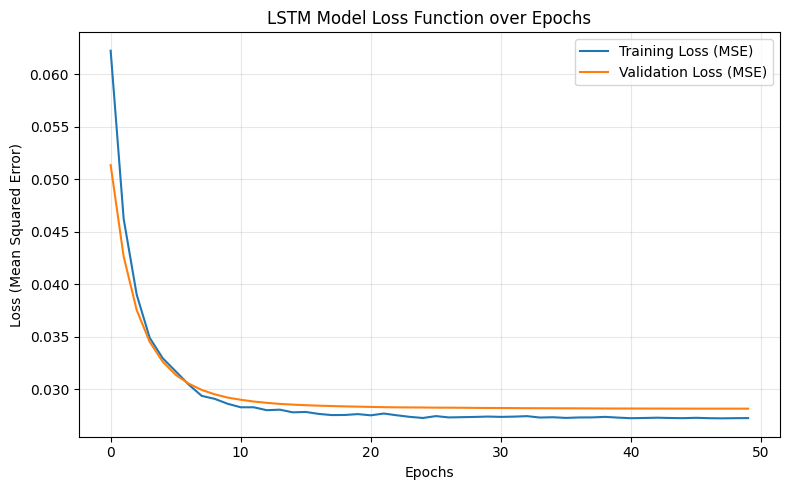

In [ ]:
plot_loss_curves(lstm_history, save_path="figures/loss_curve.png", model_name="LSTM")
plt.show()

## 3. Architecture — 1D CNN

A temporal convolutional network: a fundamentally different architectural family
from the LSTM (convolution rather than recurrence) trained with **identical**
hyperparameters and regularization.

| Layer            | Spec                                                  | Params |
|------------------|-------------------------------------------------------|-------:|
| Input            | (window=10, 1)                                        |      0 |
| Conv1D           | 32 filters, kernel=3, ReLU, causal pad, L2(0.01)      |    128 |
| Dropout          | 0.20                                                  |      0 |
| Conv1D           | 64 filters, kernel=3, ReLU, causal pad, L2(0.01)      |  6,208 |
| GlobalAvgPool1D  | (collapses time axis)                                 |      0 |
| Dropout          | 0.20                                                  |      0 |
| Dense            | 1 unit, L2(0.01)                                      |     65 |
| **Total**        |                                                      | **6,401** |

**Why this design:**
- Two stacked Conv1D layers with kernel=3 give a 5-day receptive field — enough
  for short-horizon patterns without over-parameterizing.
- `padding='causal'` keeps temporal order strict (no future leakage within window).
- GlobalAveragePooling1D collapses time to features with **zero parameters**,
  acting as a strong implicit regularizer (vs Flatten → Dense which would add
  ~640 extra parameters).
- Same Dropout, L2, and optimizer settings as LSTM for an apples-to-apples test.

In [ ]:
build_cnn(window=WINDOW).summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 10, 32)         │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 10, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 10, 64)         │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,401 (25.00 KB)

 Trainable params: 6,401 (25.00 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
cnn_model, cnn_history, cnn_scaler = train_cnn(
    daily_train, target=TARGET, window=WINDOW,
    filters=(32, 64), kernel_size=3,
    dropout=0.20, l2_coeff=0.01, lr=0.001,
    epochs=EPOCHS, batch_size=16, val_frac=0.20,
    early_stop_patience=10, seed=SEED, verbose=0,
)
cnn_metrics, cnn_preds = evaluate_on_test(
    cnn_model, cnn_scaler, daily_train, daily_test,
    target=TARGET, window=WINDOW,
)
print(f"CNN trained for {len(cnn_history.history['loss'])} epochs")
print(f"Final training MSE  : {cnn_history.history['loss'][-1]:.4f}")
print(f"Final validation MSE: {cnn_history.history['val_loss'][-1]:.4f}\n")
print("CNN test metrics:")
for k, v in cnn_metrics.items():
    print(f"  {k:>16s}: {v:,.4f}" if isinstance(v, float) else f"  {k:>16s}: {v}")

CNN trained for 50 epochs
Final training MSE  : 0.0273
Final validation MSE: 0.0281

CNN test metrics:
      rmse_dollars: 101.8310
       mae_dollars: 79.1753
          mape_pct: 112.5158
     n_test_points: 201


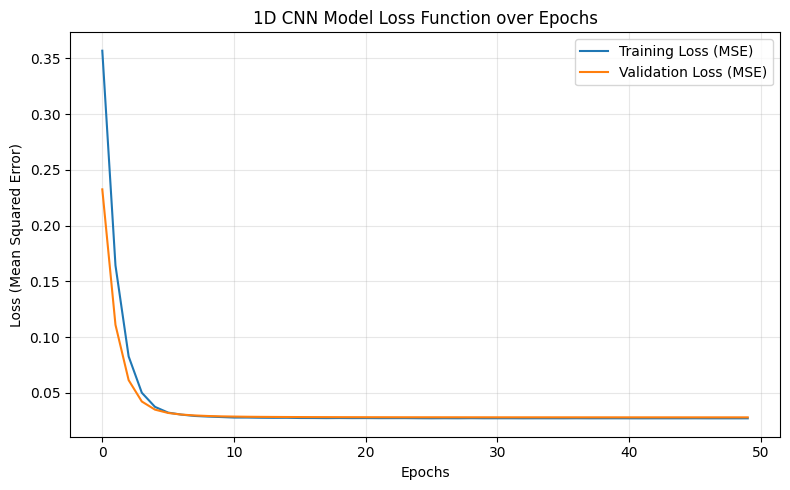

In [ ]:
plot_loss_curves(cnn_history, save_path="figures/cnn_loss_curve.png", model_name="1D CNN")
plt.show()

## 4. Comparison

In [ ]:
summary = pd.DataFrame([
    {"model": "LSTM",   "params": 10451, **lstm_metrics},
    {"model": "1D CNN", "params":  6401, **cnn_metrics},
])
summary

,model,params,rmse_dollars,mae_dollars,mape_pct,n_test_points
0,LSTM,10451,101.824988,79.117592,112.244629,201
1,1D CNN,6401,101.830958,79.175339,112.515831,201


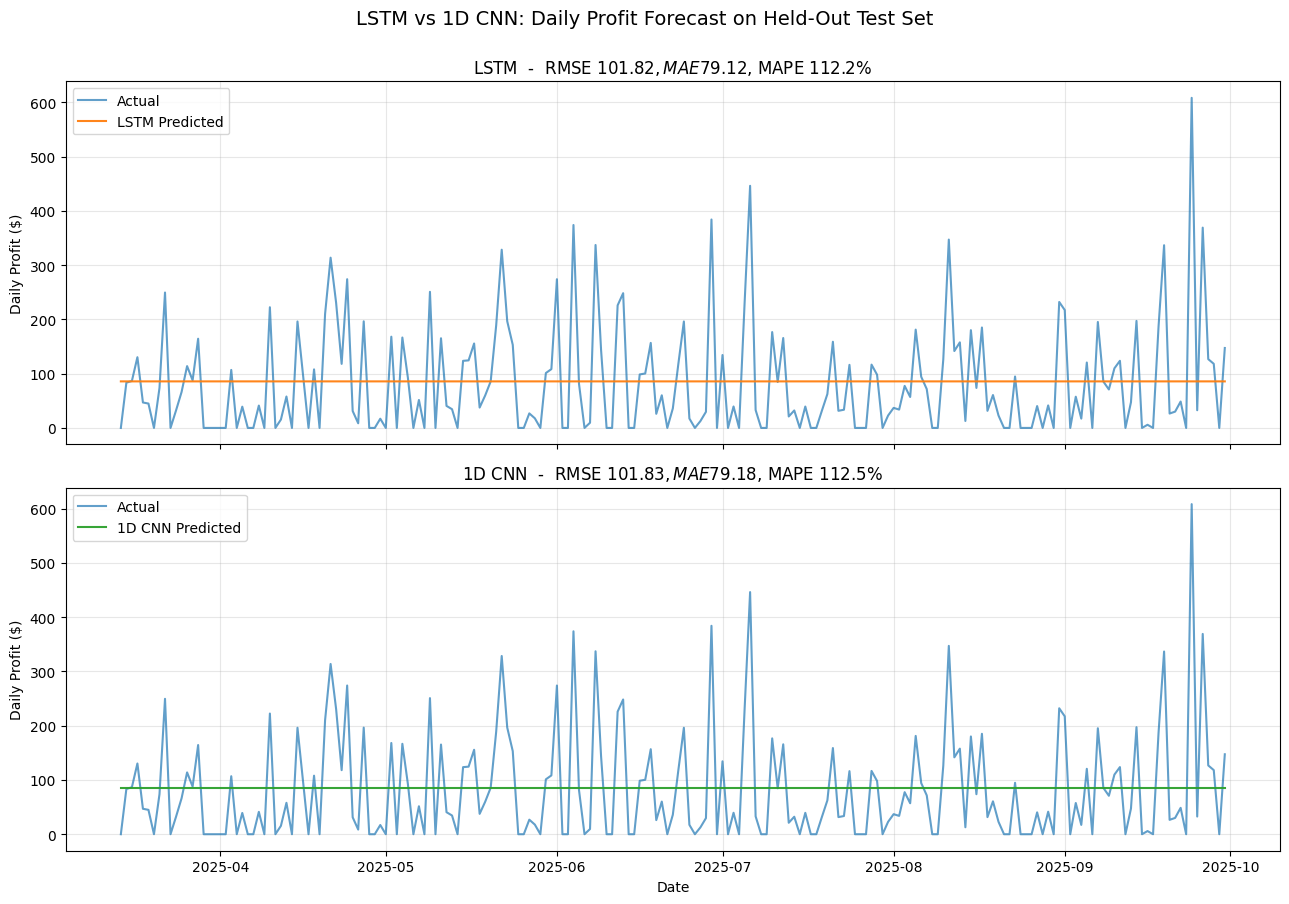

In [ ]:
# Side-by-side prediction plots
fig, axes = plt.subplots(2, 1, figsize=(13, 9), sharex=True)

for ax, preds, name, color, m in [
    (axes[0], lstm_preds, "LSTM",   "tab:orange", lstm_metrics),
    (axes[1], cnn_preds,  "1D CNN", "tab:green",  cnn_metrics),
]:
    ax.plot(preds.index, preds["actual"], label="Actual", alpha=0.7, color="tab:blue")
    ax.plot(preds.index, preds["predicted"], label=f"{name} Predicted", alpha=0.95, color=color)
    ax.set_title(f"{name}  -  RMSE ${m['rmse_dollars']:.2f}, MAE ${m['mae_dollars']:.2f}, MAPE {m['mape_pct']:.1f}%")
    ax.set_ylabel("Daily Profit ($)")
    ax.legend(loc="upper left")
    ax.grid(alpha=0.3)
axes[1].set_xlabel("Date")
fig.suptitle("LSTM vs 1D CNN: Daily Profit Forecast on Held-Out Test Set", y=1.00, fontsize=14)
fig.tight_layout()
fig.savefig("figures/lstm_vs_cnn_predictions.png", dpi=150, bbox_inches="tight")
plt.show()